# 02 — Ingesta bronze → silver y perfilado inicial

En este notebook convertimos los 5 JSON crudos (8.7 GB) a **Parquet tipado** (capa *silver*), verificamos la integridad del dataset y comparamos las 11 áreas metropolitanas para **elegir los 3 mercados** donde ejecutaremos los análisis computacionalmente intensivos (grafos, clustering).

> **Vocabulario:** llamamos *metro* a un **área metropolitana** (ciudad + suburbios), siguiendo la denominación del propio dataset ("11 metropolitan areas"). Usamos *mercado* como sinónimo.

**Limpiezas aplicadas en silver** (implementación en `src/preprocessing.py`): fechas→timestamp UTC · `friends`→array (base del grafo social) · `elite` corrige el bug histórico `"20,20"`≡2020 · check-ins explotados a 1 fila/evento · `categories`→array · columnas derivadas `metro` y `es_restaurante`.

⏱️ Tiempo de ejecución en un M1 Pro: ~2–5 min.

In [1]:
import sys, time
sys.path.append("..")

from src.config import SILVER, ensure_dirs, spark_session
from src.preprocessing import TABLAS, escribir_silver

ensure_dirs()
spark = spark_session("ingesta-silver")
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version, "listo")

26/06/18 13:50:31 WARN Utils: Your hostname, MacBook-Pro-de-johar.local resolves to a loopback address: 127.0.0.1; using 192.168.100.41 instead (on interface en0)
26/06/18 13:50:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/18 13:50:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.8 listo


## 1. Materializar las 5 tablas silver (JSON → Parquet)

In [2]:
tiempos = {}
for tabla in TABLAS:  # business, review, user, tip, checkin
    t0 = time.time()
    ruta = escribir_silver(spark, tabla)
    tiempos[tabla] = time.time() - t0
    print(f"✅ {tabla:8s} → {ruta}  ({tiempos[tabla]:.1f}s)")

✅ business → <REPO>/data/silver/business.parquet  (7.3s)


✅ review   → <REPO>/data/silver/review.parquet  (15.2s)


✅ user     → <REPO>/data/silver/user.parquet  (23.7s)


✅ tip      → <REPO>/data/silver/tip.parquet  (1.3s)


✅ checkin  → <REPO>/data/silver/checkin.parquet  (3.3s)


8.7 GB procesados en ~64 s; la tabla cara es `review` (5 GB dominados por texto). Spark reparte la lectura del JSON línea-a-línea entre los cores del M1 Pro — con un solo hilo esto tomaría varios minutos y picos de RAM difíciles de manejar.

In [3]:
# Compresión lograda: JSON crudo vs Parquet (argumento para el informe)
import subprocess
print(subprocess.run(["du", "-sh", *[str(SILVER / f"{t}.parquet") for t in TABLAS]],
                     capture_output=True, text=True).stdout)

 21M	<REPO>/data/silver/business.parquet
3.1G	<REPO>/data/silver/review.parquet
2.6G	<REPO>/data/silver/user.parquet
 77M	<REPO>/data/silver/tip.parquet
140M	<REPO>/data/silver/checkin.parquet



la compresión columnar es selectiva: `business` cae 114→21 MB (−82%), pero `review` (3.1 GB) y `user` (2.6 GB) apenas se reducen porque el texto libre y los arrays de amigos no comprimen bien. Conclusión de diseño: las tablas *gold* llevarán **solo las columnas que cada análisis use**.

## 2. Verificación de integridad
Conteos esperados (página oficial): 150,346 negocios · 6,990,280 reseñas · ~1.99M usuarios.

In [4]:
dfs = {t: spark.read.parquet(str(SILVER / f"{t}.parquet")) for t in TABLAS}
for t, df in dfs.items():
    print(f"{t:8s} filas = {df.count():>12,}")

business filas =      150,346
review   filas =    6,990,280


user     filas =    1,987,897
tip      filas =      908,915
checkin  filas =   13,356,875


los conteos coinciden exactamente con las cifras oficiales de Yelp — la descarga está íntegra. Cuantificamos además lo que la página oficial no detalla: 908,915 tips y 13,356,875 eventos de check-in (estos últimos serán nuestro *stream* en la Parte V).

In [5]:
from pyspark.sql import functions as F
rev, biz, usr = dfs["review"], dfs["business"], dfs["user"]

print("review_id duplicados:", rev.count() - rev.select("review_id").distinct().count())
print("business_id duplicados:", biz.count() - biz.select("business_id").distinct().count())
print("user_id duplicados:", usr.count() - usr.select("user_id").distinct().count())

print("\nRango de fechas de reseñas:")
rev.select(F.min("date"), F.max("date")).show(truncate=False)

print("Nulos en columnas clave de business:")
biz.select([F.sum(F.col(c).isNull().cast("int")).alias(c)
            for c in ["city", "state", "postal_code", "latitude", "categories"]]).show()

print("Integridad referencial: reseñas cuyo negocio NO existe en business:")
print(rev.join(biz.select("business_id"), "business_id", "left_anti").count())

review_id duplicados: 0


business_id duplicados: 0


user_id duplicados: 0

Rango de fechas de reseñas:


+-------------------+-------------------+
|min(date)          |max(date)          |
+-------------------+-------------------+
|2005-02-16 03:23:22|2022-01-19 19:48:45|
+-------------------+-------------------+

Nulos en columnas clave de business:


+----+-----+-----------+--------+----------+
|city|state|postal_code|latitude|categories|
+----+-----+-----------+--------+----------+
|   0|    0|          0|       0|       103|
+----+-----+-----------+--------+----------+

Integridad referencial: reseñas cuyo negocio NO existe en business:


0


0 duplicados y 0 reseñas huérfanas: las identidades vienen curadas de origen, de modo que el esfuerzo real de limpieza estará en atributos y texto (notebook 03). Solo 103 negocios (0.07%) carecen de categorías y quedan fuera del universo de restaurantes. El máximo de fecha confirma el **corte el 19-ene-2022**, clave para no malinterpretar las series anuales.

## 3. Comparación de áreas metropolitanas → elección de los 3 mercados

Necesitamos un subuniverso donde los algoritmos super-lineales (Girvan-Newman, CURE, DBSCAN) corran sin degradarse, manteniendo masa de datos y diversidad de mercados. Seleccionamos **mercados completos** —y no reseñas al azar— porque es *key-based sampling* (semana 06): conserva el grafo social y las co-ocurrencias usuario↔negocio que el filtrado colaborativo necesita.

Esta elección es una **hipótesis de trabajo**: al llegar a grafos (Parte II) y clustering (Parte III) re-validaremos tamaños y tiempos sobre las tablas reales y, de ser necesario, ajustaremos el subuniverso con esa evidencia.

In [6]:
rev_biz = dfs["review"].join(dfs["business"].select("business_id", "metro", "es_restaurante"), "business_id")

tabla_metros = (
    dfs["business"].groupBy("metro").agg(
        F.count("*").alias("negocios"),
        F.sum(F.col("es_restaurante").cast("int")).alias("restaurantes"),
        F.round(F.avg("stars"), 2).alias("stars_prom"),
    )
    .join(rev_biz.groupBy("metro").agg(
        F.count("*").alias("reseñas"),
        F.sum(F.col("es_restaurante").cast("int")).alias("reseñas_restaurantes"),
        F.countDistinct("user_id").alias("usuarios_activos"),
    ), "metro")
    .orderBy(F.desc("reseñas_restaurantes"))
)
pdf_metros = tabla_metros.toPandas()
pdf_metros

,metro,negocios,restaurantes,stars_prom,reseñas,reseñas_restaurantes,usuarios_activos
0,Philadelphia,44840,16943,3.54,1930159,1320587,513954
1,Tampa,26330,8731,3.61,1161545,792133,348697
2,New Orleans,9924,3640,3.68,761673,558340,273391
3,Nashville,12056,4352,3.57,614388,434697,222122
4,Saint Louis,13058,5230,3.52,554217,391475,165174
5,Indianapolis,11247,4150,3.59,489752,335843,129736
6,Tucson,9912,2671,3.59,431708,267036,126306
7,Reno,7715,1673,3.74,430678,243594,134285
8,Santa Barbara,5203,1161,4.00,348856,211748,155949
9,Boise,4467,1302,3.71,157572,100065,56962


la media de estrellas (3.45–4.00) casi no discrimina entre mercados; la **intensidad** (reseñas por restaurante) sí: Santa Barbara 182, New Orleans 153 y Reno 146 dibujan mercados turístico-gastronómicos, frente a Philadelphia 78 y Saint Louis 75, residenciales. Edmonton es el mercado más pequeño (68.9k reseñas) y además carece de cobertura ACS/COVID por ser canadiense.

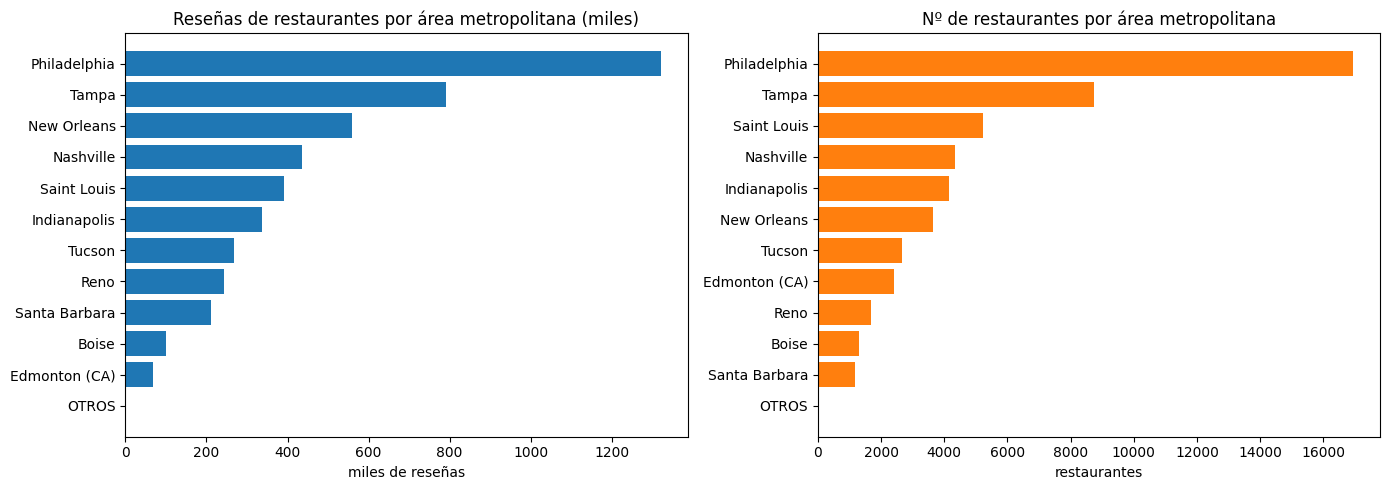

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
d = pdf_metros.sort_values("reseñas_restaurantes", ascending=True)
axes[0].barh(d["metro"], d["reseñas_restaurantes"] / 1e3, color="#1f77b4")
axes[0].set_title("Reseñas de restaurantes por área metropolitana (miles)")
axes[0].set_xlabel("miles de reseñas")

d2 = pdf_metros.sort_values("restaurantes", ascending=True)
axes[1].barh(d2["metro"], d2["restaurantes"], color="#ff7f0e")
axes[1].set_title("Nº de restaurantes por área metropolitana")
axes[1].set_xlabel("restaurantes")
plt.tight_layout(); plt.show()

Philadelphia lidera con holgura (1.32M reseñas de restaurantes, 1.7× Tampa) y la cola es larga: los 3 primeros mercados acumulan 2.67M = **56.5% del total**. Esa concentración permite cubrir más de la mitad del fenómeno con solo 3 mercados.

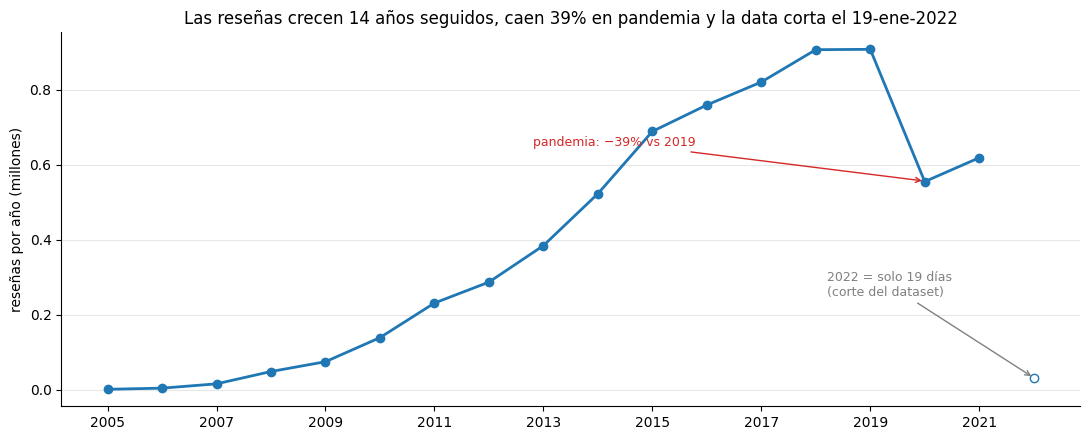

In [8]:
# Evolución anual de reseñas (contexto para la Parte V y el cruce COVID)
por_anio = (dfs["review"].groupBy(F.year("date").alias("anio"))
            .count().orderBy("anio").toPandas())

fig, ax = plt.subplots(figsize=(11, 4.5))
completos = por_anio[por_anio["anio"] < 2022]
ax.plot(completos["anio"], completos["count"] / 1e6, marker="o", lw=2, color="#1f77b4")

# 2022 solo tiene 19 días de datos: lo mostramos como punto abierto, no como caída real
p2022 = por_anio.loc[por_anio["anio"] == 2022, "count"].iloc[0] / 1e6
ax.scatter([2022], [p2022], facecolor="white", edgecolor="#1f77b4", zorder=3)
ax.annotate("2022 = solo 19 días\n(corte del dataset)", xy=(2022, p2022), xytext=(2018.2, 0.25),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray")
ax.annotate("pandemia: −39% vs 2019", xy=(2020, 0.556), xytext=(2012.8, 0.65),
            arrowprops=dict(arrowstyle="->", color="#d62728"), fontsize=9, color="#d62728")

ax.set_xticks(range(2005, 2023, 2))   # años enteros, sin 2012.5
ax.set_title("Las reseñas crecen 14 años seguidos, caen 39% en pandemia y la data corta el 19-ene-2022")
ax.set_ylabel("reseñas por año (millones)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

el punto abierto de 2022 evita una conclusión errada — no hay desplome, hay 19 días de datos. La señal verdadera es el valle de 2020 (**−39% vs 2019**) con recuperación parcial en 2021: exactamente la ventana que cruzaremos con los datos COVID en la Parte V.

In [9]:
spark.stop(); print("Ingesta silver completa ✅")

Ingesta silver completa ✅


## Resumen del notebook

- Materializamos la capa **silver** (5 tablas Parquet tipadas, 8.7→6.0 GB) en ~64 s con Spark local.
- Verificamos integridad total: conteos idénticos a los oficiales (150,346 negocios / 6,990,280 reseñas / 1,987,897 usuarios), 0 duplicados, 0 reseñas huérfanas; rango temporal 16-feb-2005 → 19-ene-2022.
- Encontramos tres lecturas que guían el diseño: **concentración** (3 mercados reúnen el 56.5% de las reseñas de restaurantes), **arquetipos por intensidad** (turístico: 146–182 reseñas/local vs residencial: 75–78) y el **artefacto de corte** de 2022.
- Elegimos como núcleo analítico **Philadelphia + Tampa + New Orleans** (masa, diversidad de arquetipos y cobertura de fuentes externas de EE.UU.) y definimos *restaurante* = categoría exacta `Restaurants` (canónica y reproducible; la sensibilidad `∪ Food` se reporta en el EDA).
- **Siguiente paso:** notebook 03 — limpieza fina de atributos, EDA profundo y construcción de tablas *gold* (grafo social, grafo bipartito, matriz usuario×negocio).